In [1]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import random

In [2]:
def generate_random_polygon(num_vertices, x_range, y_range):
    """
    Generate a random polygon without crossing lines
    """
    vertices = np.random.rand(num_vertices, 2) * [x_range, y_range]
    vertices = sort_vertices(vertices)
    for _ in range(num_vertices * 2):
        for i in range(num_vertices):
            prev_i = (i - 1) % num_vertices
            next_i = (i + 1) % num_vertices
            v1 = vertices[prev_i]
            v2 = vertices[i]
            v3 = vertices[next_i]
            new_v2 = v2 + 0.01 * np.random.randn(2)
            if not is_crossing(v1, new_v2, v3, vertices):
                vertices[i] = new_v2
    return vertices

In [3]:
def sort_vertices(vertices):
    """
    Sort vertices by their angle
    """
    center = np.mean(vertices, axis=0)
    angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
    return vertices[np.argsort(angles)]

In [4]:
def is_crossing(p1, p2, p3, vertices):
    """
    Check if line segment (p1, p2) intersects with any line segment 
    in a list of segments
    """
    for i in range(len(vertices)):
        p4 = vertices[(i + 1) % len(vertices)]
        if is_intersect(p1, p2, p3, p4):
            return True
    return False

In [5]:
def is_intersect(p1, p2, p3, p4):
    """
    Check if line segment (p1, p2) intersects with line segment (p3, p4)
    """
    def ccw(A, B, C):
        return (C[1]-A[1]) * (B[0]-A[0]) > (B[1]-A[1]) * (C[0]-A[0])

    return ccw(p1, p3, p4) != ccw(p2, p3, p4) and ccw(p1, p2, p3) != ccw(p1, p2, p4)

In [6]:
def is_inside_polygon(point, vertices):
    """
    Check if a point (x, y) is inside a polygon
    """
    n = len(vertices)
    inside = False
    p1x, p1y = vertices[0]
    for i in range(1, n + 1):
        p2x, p2y = vertices[i % n]
        if point[1] > min(p1y, p2y):
            if point[1] <= max(p1y, p2y):
                if point[0] <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (point[1] - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or point[0] <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y
    return inside

In [7]:
def generate_random_points_within_polygon(vertices, num_points):
    min_x, min_y = np.min(vertices, axis=0)
    max_x, max_y = np.max(vertices, axis=0)
    points = []
    while len(points) < num_points:
        random_point = np.random.rand(2) * [max_x - min_x, max_y - min_y] + [min_x, min_y]
        if is_inside_polygon(random_point, vertices):
            points.append(random_point)
    return np.array(points)

In [8]:
def generate_regular_grid_points_within_polygon(vertices, grid_spacing):
    min_x, min_y = np.min(vertices, axis=0)
    max_x, max_y = np.max(vertices, axis=0)
    
    points = []
    for x in np.arange(min_x, max_x, grid_spacing):
        for y in np.arange(min_y, max_y, grid_spacing):
            point = [x, y]
            if is_inside_polygon(point, vertices):
                points.append(point)
    
    return np.array(points)

In [9]:
def filter_triangles_by_edge_length(triangles, threshold):
    """
    Filter out triangles with edge lengths exceeding a threshold
    """
    triangles = []
    for simplex in tri.simplices:
        triangle_vertices = points[simplex]
        edge_lengths = np.linalg.norm(np.roll(triangle_vertices, -1, axis=0) - triangle_vertices, axis=1)
        if np.all(edge_lengths <= threshold):
            triangles.append(simplex)


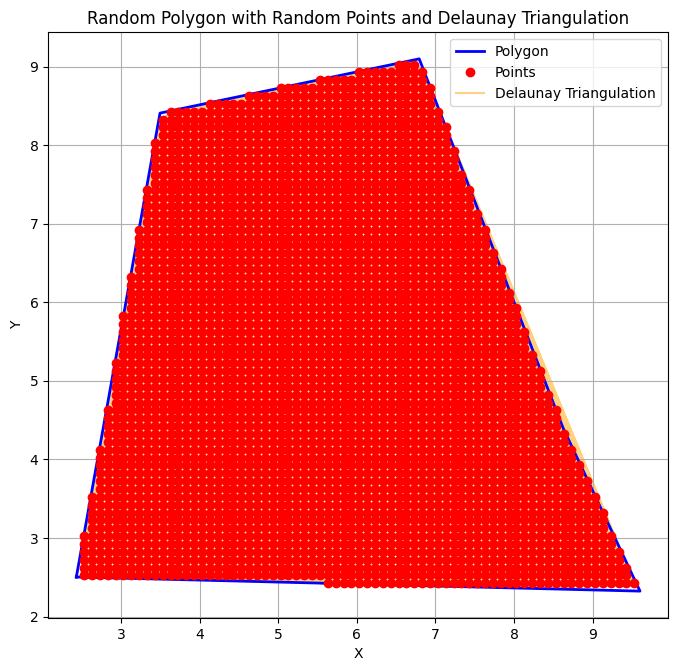

In [10]:
n_vertices = np.random.randint(3, 25)  # Random number of vertices
x_range = 10  # Range of x-values for vertices
y_range = 10  # Range of y-values for vertices
polygon_vertices = generate_random_polygon(n_vertices, x_range, y_range)

n_points = 1000
# points = generate_random_points_within_polygon(polygon_vertices, num_points)
points = generate_regular_grid_points_within_polygon(polygon_vertices, grid_spacing=0.1)

tri = Delaunay(points)

plt.figure(figsize=(8, 8))

plt.plot(np.append(polygon_vertices[:, 0], polygon_vertices[0, 0]), np.append(polygon_vertices[:, 1], polygon_vertices[0, 1]), color='blue', linewidth=2, label='Polygon')
plt.plot(points[:, 0], points[:, 1], 'o', color='red', label='Points')
plt.triplot(points[:, 0], points[:, 1], tri.simplices, color='orange', alpha=0.5, label='Delaunay Triangulation')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Random Polygon with Random Points and Delaunay Triangulation')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

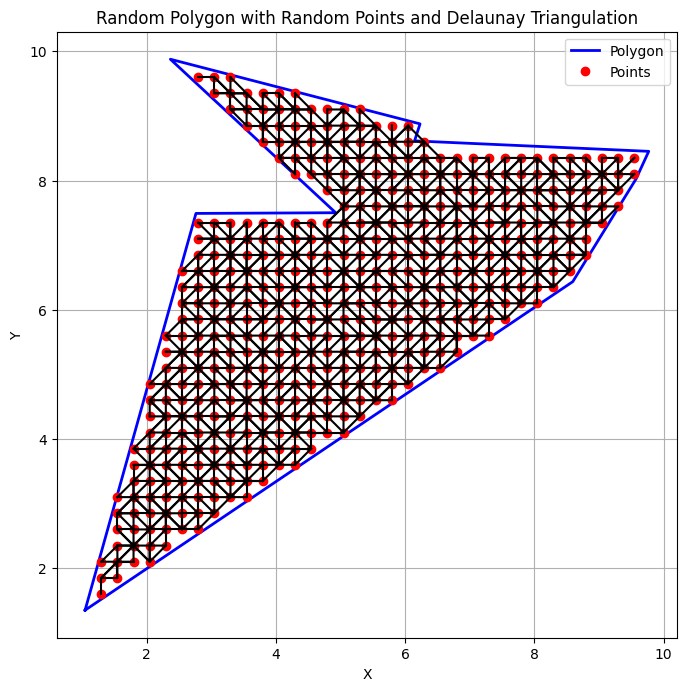

In [21]:
n_vertices = np.random.randint(3, 10)  # Random number of vertices
x_range = 10  # Range of x-values for vertices
y_range = 10  # Range of y-values for vertices
polygon_vertices = generate_random_polygon(n_vertices, x_range, y_range)

n_points = 1000
# points = generate_random_points_within_polygon(polygon_vertices, num_points)
points = generate_regular_grid_points_within_polygon(polygon_vertices, grid_spacing=0.25)

tri = Delaunay(points)

# Filter out triangles with edge lengths exceeding a threshold
threshold = .5  # Set the maximum length for an edge
triangles = []
for simplex in tri.simplices:
    triangle_vertices = points[simplex]
    edge_lengths = np.linalg.norm(np.roll(triangle_vertices, -1, axis=0) - triangle_vertices, axis=1)
    if np.all(edge_lengths <= threshold):
        triangles.append(simplex)

plt.figure(figsize=(8, 8))
plt.plot(np.append(polygon_vertices[:, 0], polygon_vertices[0, 0]), np.append(polygon_vertices[:, 1], polygon_vertices[0, 1]), color='blue', linewidth=2, label='Polygon')
plt.plot(points[:, 0], points[:, 1], 'o', color='red', label='Points')

for simplex in triangles:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Random Polygon with Random Points and Delaunay Triangulation')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

In [20]:
print(triangles)

[array([377, 375, 376], dtype=int32), array([13,  9,  8], dtype=int32), array([4, 3, 2], dtype=int32), array([141, 142, 117], dtype=int32), array([201, 234, 235], dtype=int32), array([5, 4, 8], dtype=int32), array([5, 3, 4], dtype=int32), array([248, 247, 272], dtype=int32), array([172, 173, 143], dtype=int32), array([119,  95, 118], dtype=int32), array([280, 279, 297], dtype=int32), array([299, 298, 315], dtype=int32), array([115, 116,  94], dtype=int32), array([92, 93, 75], dtype=int32), array([364, 368, 369], dtype=int32), array([39, 38, 49], dtype=int32), array([38, 29, 28], dtype=int32), array([238, 202, 237], dtype=int32), array([341, 329, 328], dtype=int32), array([313, 329, 314], dtype=int32), array([296, 313, 314], dtype=int32), array([296, 271, 295], dtype=int32), array([59, 48, 58], dtype=int32), array([366, 370, 367], dtype=int32), array([372, 374, 375], dtype=int32), array([375, 374, 376], dtype=int32), array([25, 26, 19], dtype=int32), array([17, 12, 16], dtype=int32), ar

### Randomly select a subset of edges from the Delaunay triangulation